## Imports and load data

In [35]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.dates import MonthLocator
from sklearn import preprocessing, model_selection, linear_model, metrics
import warnings

warnings.filterwarnings('ignore')  # Ignore warnings to avoid clutter in notebook

# Load all datasets
engine = create_engine('sqlite:///db/olist.db')
customers = pd.read_csv('data/olist_customers_dataset.csv')
geolocations = pd.read_csv('data/olist_geolocation_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
categories = pd.read_csv('data/product_category_name_translation.csv')

dataset_map = {
    'customers': customers, 
    'geolocations': geolocations,
    'order_items': order_items, 
    'payments': payments,
    'reviews': reviews, 
    'orders': orders,
    'products': products, 
    'sellers': sellers, 
    'categories': categories
    }

# Data Cleaning

In [36]:
# Check null values in each dataset to determine whether to delete or impute
for name, df in dataset_map.items():
    null_count = df.isnull().sum()
    null_count = null_count[null_count > 0]
    if not null_count.empty:
        print(f"Number of rows in {name}: {len(df)}")
        print(f"{name} - Null Values:\n{null_count}\n")

Number of rows in reviews: 99224
reviews - Null Values:
review_comment_title      87656
review_comment_message    58247
dtype: int64

Number of rows in orders: 99441
orders - Null Values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Number of rows in products: 32951
products - Null Values:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64



The reviews dataset has two columns with high null counts: review_comment_title (88.3%) will be dropped, while review_comment_message (58.7%) will be kept for potential sentiment analysis later on in the project. A boolean `has_review_message` column will also be created to flag whether a customer left a review message. This makes it easier for filtering and analysis

In the orders dataset, three date columns have null rates under 3%, which likely reflects cancelled or undelivered orders. These rows will be dropped as the proportion is insignificant.

The products dataset has 610 rows missing across four descriptive columns (1.85%) which will be dropped, and the 2 nulls in the dimension columns will be resolved through median imputation.

In [37]:
# Reviews
reviews.drop(columns=['review_comment_title', 'review_id'], inplace=True)
reviews['has_review_message'] = reviews['review_comment_message'].notna() # Add boolean flag

# Orders
orders.dropna(subset=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date'], inplace=True)

orders['delivery_delay'] = (pd.to_datetime(orders['order_delivered_customer_date']) - pd.to_datetime(orders['order_estimated_delivery_date'])).dt.days
orders['processing_time'] = (pd.to_datetime(orders['order_delivered_carrier_date']) - pd.to_datetime(orders['order_purchase_timestamp'])).dt.days
orders['order_month'] = pd.to_datetime(orders['order_purchase_timestamp']).dt.month
orders['day_of_week'] = pd.to_datetime(orders['order_purchase_timestamp']).dt.dayofweek
orders['month/year'] = pd.to_datetime(orders['order_purchase_timestamp']).dt.to_period('M')

# Products 
products.drop(columns = ['product_name_lenght'], inplace = True)
products.dropna(subset=['product_category_name', 'product_description_lenght', 'product_photos_qty'], inplace=True)

# Products
products.fillna(products.median(numeric_only=True), inplace=True) # Impute NA values with median

In [38]:
# Given the orders dataset uses a brand new customer_id for each order, I will perform a left join on the customer dataset, adding the customer_unique_id to matches on the existing customer_id.
# This helps us track repeat customers and their orders
orders = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

# Exploratory Data Analysis

We start by examining the descriptive statistics of each dataset to understand the distribution of the numerical data, identify any outliers or data quality concerns. We will then move into visualisations to uncover trends and patterns across sales, product categories, delivery performance, and customer sentiment.

In [39]:
# Dimensions (rows, columns) and descriptive statistics for each dataset
for name, dataset in dataset_map.items():
    print(f"For {name}: {dataset.shape}")
    print(dataset.describe())

For customers: (99441, 5)
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000
For geolocations: (1000163, 5)
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                 1.000163e+06     1.000163e+06     1.000163e+06
mean                  3.657417e+04    -2.117615e+01    -4.639054e+01
std                   3.054934e+04     5.715866e+00     4.269748e+00
min                   1.001000e+03    -3.660537e+01    -1.014668e+02
25%                   1.107500e+04    -2.360355e+01    -4.857317e+01
50%                   2.653000e+04    -2.291938e+01    -4.663788e+01
75%                   6.350400e+04    -1.997962e+01    -4.376771e+01
max                   9.999000e+04     4.506593e+01     1.211054e+02
For order_items: (112650, 7)
     

In the payments data, payment_value has a mean of R$154, but a maximum value of R$13664. Given we see that the 75% percentile is at R$171, this is definitely an outlier, but more so a reflection on a small number of high-value purchases. We also see that the minimum value for payment_installments is 0 - which might suggests that nulls (no payment installments) were encoded as zeros.

From the order_items datasets, we see that the price of orders range from R$0.85 to R$6735, with an interquartile range of R$40 and R$140. This range gives us a sense of the most common price range customers purchase within. More poignant is the fact that customers mostly buy only 1 line item. This suggests customers are largely making single, purposeful purchases rather than browsing and adding multiple items.

Finally, the review scores are strongly skewed toward positive ratings with a mean of 4.1 and a median of 5. This suggests that the low-score reviews represent a small but valuable group to analyse - we will look into this further in our sentiment analysis.

Orders are the heart and core of any e-commerce platform, I will start my analysis here.

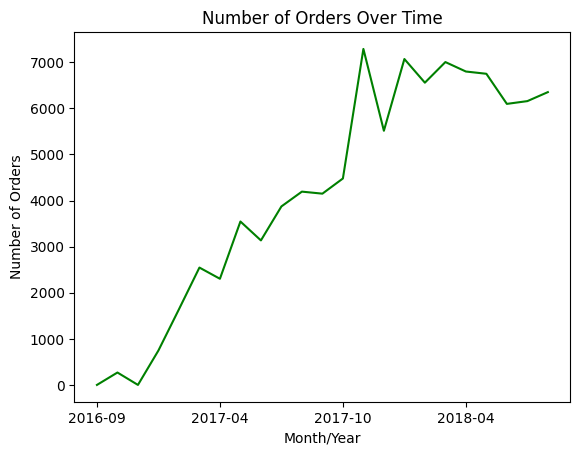

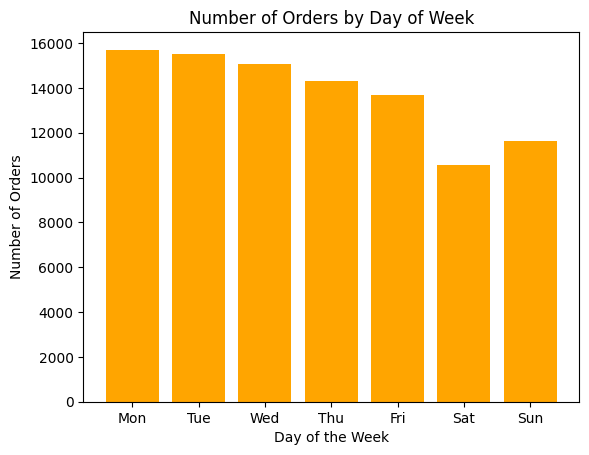

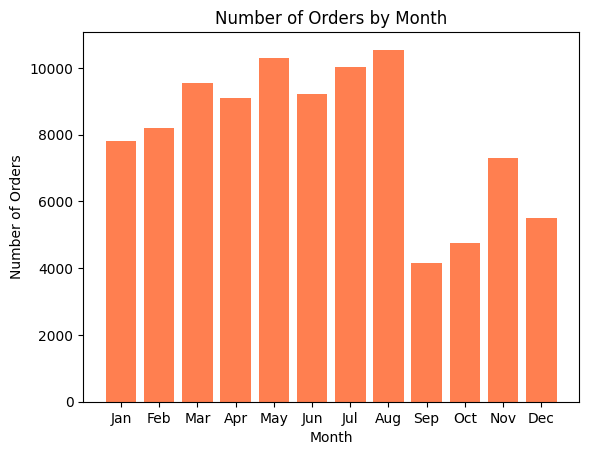

In [66]:
monthly_orders = orders.groupby('month/year').size()
days_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.plot(monthly_orders.index.astype(str), monthly_orders.values, color = 'green')
plt.xlabel('Month/Year')
plt.ylabel('Number of Orders')
plt.title('Number of Orders Over Time')
plt.xticks(monthly_orders.index.astype(str)[::6])
plt.show()

plt.bar(days_labels, orders['day_of_week'].value_counts().sort_index(), color = 'orange')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.title('Number of Orders by Day of Week')
plt.show()


plt.bar(months_labels, orders['order_month'].value_counts().sort_index(), color = 'coral')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.title('Number of Orders by Month')
plt.show()


The orders on the Olist e-commerce platform tell a clear growth story. Starting from near zero in late 2016, order volume climbed steadily through 2017, peaking around November at over 7,000 orders before settling into a stable 6,000–7,000 range, a sign of a platform maturing into consistent demand after early adoption.

Looking at the calendar, demand runs hottest between March and August, peaking in August at over 10,000 orders. September sees a dramatic drop, nearly halving from August's peak orders. This could reflect a genuine post-winter spending cool-down in Brazil as the spring season settles in, with no major retail events to drive purchases. October remains sluggish before a partial recovery in November. That said, the dip between September and December could also partly be a dataset coverage issue, as the data only spans late 2016 through mid-2018, these months have fewer years of data to aggregate across, so the figures would naturally be expected to be lower, and therefore should be considered with caution.

At the weekly level, orders on Olist peak on Monday, then gradually decline as the week progresses, hitting their lowest point on Saturday before a slight recovery on Sunday. This suggests that Olist's core customer base shops during the working week, probably during work or commute hours, making early in the week the prime window for marketing campaigns and promotions.

Understanding how customers feel starts with understanding how well their orders actually arrive. Delivery performance is one of the most direct drivers of customer satisfaction, so before diving into reviews and ratings, it is worth examining where delays occur, how long they last, and which regions are most affected.

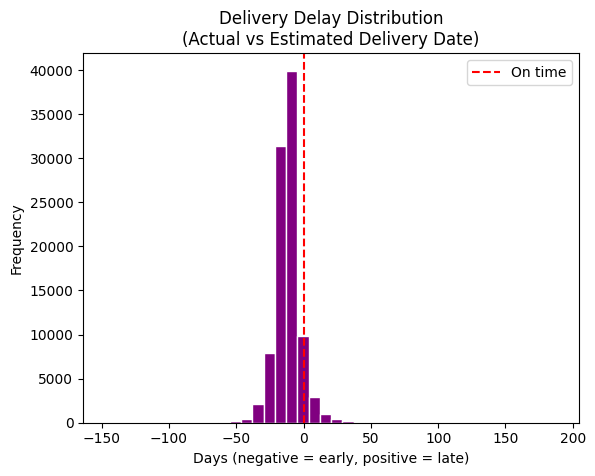

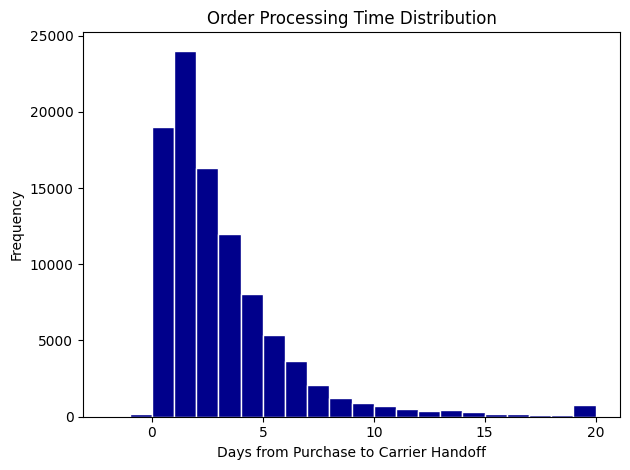

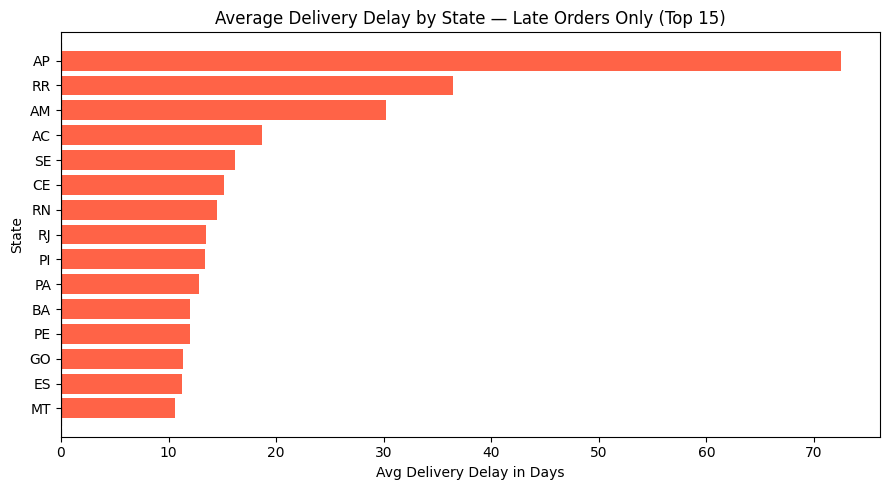

In [94]:
plt.hist(orders['delivery_delay'], bins = 40, color = 'purple', edgecolor = 'white')
plt.axvline(0, color = 'red', linestyle = '--', label = 'On time')
plt.xlabel('Days (negative = early, positive = late)')
plt.ylabel('Frequency')
plt.title('Delivery Delay Distribution\n(Actual vs Estimated Delivery Date)')
plt.legend()
plt.show()

plt.hist(orders['processing_time'].clip(-2, 20), bins = 22, color = 'darkblue', edgecolor = 'white')
plt.xlabel('Days from Purchase to Carrier Handoff')
plt.ylabel('Frequency')
plt.title('Order Processing Time Distribution')
plt.tight_layout()
plt.show()

orders_with_state = orders.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

late_orders = orders_with_state[orders_with_state['delivery_delay'] > 0]

late_by_state = late_orders.groupby('customer_state')['delivery_delay'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
plt.barh(late_by_state.index[::-1], late_by_state.values[::-1], color='tomato')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Avg Delivery Delay in Days')
plt.ylabel('State')
plt.title('Average Delivery Delay by State — Late Orders Only (Top 15)')
plt.tight_layout()
plt.show()

Most orders actually arrive ahead of schedule, which speaks well of Olist's logistics network on the whole. That said, the late delivery tail stretches out to nearly 200 days, which is a clear sign that some of the orders have serious fulfilment problems. Seller processing times are generally quick at 1–3 days, though some sellers are noticeably slow to hand off to carriers, which likely snowballs and compounds into the delays seen downstream. 

Unsurprisingly, states in Brazil's north and northeast (Amapá, Roraima, and Amazonas) show the worst average delays by a significant margin, which points more to a geographical and infrastructure barrier than a seller problem.

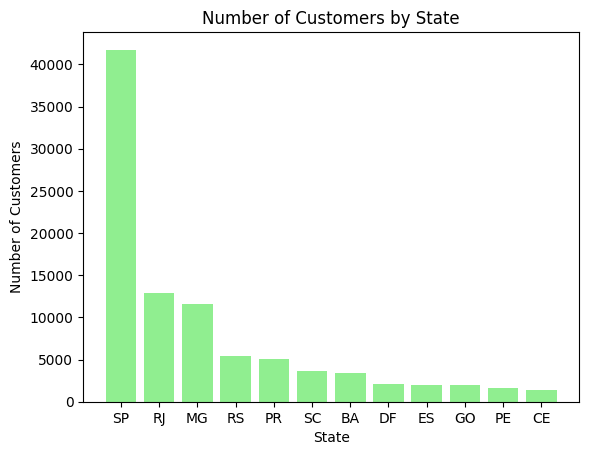

In [88]:
top8_states = customers['customer_state'].value_counts().head(12)

plt.bar(top8_states.index, top8_states.values, color='lightgreen')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.title('Number of Customers by State')
plt.show()